# Text Mining — Don Quijote (Python)
Este notebook replica el análisis del script R `Text Mining - Don Quijote.R` en Python: carga de PDFs, limpieza, tokenización, conteos, wordcloud, bigramas y grafo de co-ocurrencia.

**Suposiciones:** Los archivos `DONQUIJOTE_PARTE1.pdf` y `DONQUIJOTE_PARTE2.pdf` están en la misma carpeta `task3/`.

**Estructura:**
1. Instalación / requisitos
2. Carga de PDFs
3. Limpieza y segmentación en frases
4. Tokenización y stopwords (es)
5. Conteos y visualizaciones
6. Bigramas y grafo

In [1]:
!pip install pdfplumber pandas nltk wordcloud matplotlib seaborn scikit-learn networkx pyvis tqdm requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 61.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 94.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.0 MB/s eta 0:00:00


In [2]:
# Requerimientos: ejecutar una vez para instalar paquetes (opcional)
# !pip install pdfplumber pandas nltk wordcloud matplotlib seaborn scikit-learn networkx pyvis tqdm

# Importar librerías
import os
import re
import pdfplumber
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import networkx as nx
from itertools import combinations
from tqdm import tqdm
import requests
import io

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

print('librerias cargadas')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...


librerias cargadas


[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
base_url = "https://raw.githubusercontent.com/Jero2110/Big_Data_Phase03/main/analisis/data/"
urls = [
    base_url + 'DONQUIJOTE_PARTE1.pdf',
    base_url + 'DONQUIJOTE_PARTE2.pdf'
]

def read_pdf_from_url(url):
    try:
        response = requests.get(url)
        # Verifica si la descarga fue exitosa (status 200)
        response.raise_for_status()
        
        # Convierte los bytes en un flujo de datos que pdfplumber entiende
        with pdfplumber.open(io.BytesIO(response.content)) as pdf:
            text_pages = []
            for p in pdf.pages:
                text_pages.append(p.extract_text())
            return text_pages
            
    except requests.exceptions.RequestException as e:
        print(f"Error al descargar {os.path.basename(url)}: {e}")
        return None

# 2. Procesar los archivos
texto01 = read_pdf_from_url(urls[0])
texto02 = read_pdf_from_url(urls[1])

if not texto01 or not texto02:
    print("ATENCIÓN: No se pudieron obtener todos los archivos desde GitHub.")

In [4]:
# 2. Unir y limpiar texto
texto = ' '.join(texto01 + texto02)
# Remover retornos de carro y saltos de linea
texto = texto.replace('\r', ' ').replace('\n', ' ')
# Remover enlaces comunes y repetidos de cabecera/pie
texto = re.sub(r'http[s]?://\S+', '', texto)
# Remplazar multiples espacios por uno
texto = re.sub(r'\s+', ' ', texto).strip()

# Segmentar en frases por punto
frases = [s.strip() for s in re.split(r'\. ', texto) if s.strip()]
df = pd.DataFrame({'frase': frases})
df.head()

,frase
0,El Ingenioso Hidalgo Don Quijote de la Mancha ...
1,"Quijote de la Mancha En un lugar de la Mancha,..."
2,"Una olla de algo más vaca que carnero, salpicó..."
3,"El resto della concluían sayo de velarte, calz..."
4,Tenía en su casa una ama que pasaba de los cua...


In [5]:
# 3. Limpieza manual similar al script R
removals = ['El Ingenioso Hidalgo Don Quijote de la Mancha','PRIMERA PARTE','Miguel de Cervantes Saavedra','Portal Educativo EducaCYL']
for r in removals:
    df['frase'] = df['frase'].str.replace(r, '', regex=False)
df['frase'] = df['frase'].str.strip()
df = df[df['frase'] != '']
df = df.reset_index(drop=True)
df.head()

,frase
0,() CAPÍTULO 1: Que trata de la condición y ...
1,"Quijote de la Mancha En un lugar de la Mancha,..."
2,"Una olla de algo más vaca que carnero, salpicó..."
3,"El resto della concluían sayo de velarte, calz..."
4,Tenía en su casa una ama que pasaba de los cua...


In [6]:
# 4. Tokenizacion y stopwords en español
sw = set(stopwords.words('spanish'))
# Añadir palabras adicionales del script R
sw.update(['capítulo','d'])

def tokenize_and_filter(text):
    tokens = [w.lower() for w in word_tokenize(text, language='spanish') if re.search('[a-zA-Zñáéíóúü]', w)]
    tokens = [t for t in tokens if t not in sw and len(t) > 1]
    return tokens

df['tokens'] = df['frase'].apply(tokenize_and_filter)
df.head()

,frase,tokens
0,() CAPÍTULO 1: Que trata de la condición y ...,"[trata, condición, ejercicio, famoso, hidalgo]"
1,"Quijote de la Mancha En un lugar de la Mancha,...","[quijote, mancha, lugar, mancha, cuyo, nombre,..."
2,"Una olla de algo más vaca que carnero, salpicó...","[olla, vaca, carnero, salpicón, noches, duelos..."
3,"El resto della concluían sayo de velarte, calz...","[resto, della, concluían, sayo, velarte, calza..."
4,Tenía en su casa una ama que pasaba de los cua...,"[casa, ama, pasaba, cuarenta, sobrina, llegaba..."


In [7]:
# 5. Conteo de palabras
all_tokens = [t for tokens in df['tokens'] for t in tokens]
counts = Counter(all_tokens)
top40 = counts.most_common(40)
pd.DataFrame(top40, columns=['word','count']).set_index('word')

,count
word,
don,2675
si,1958
quijote,1763
sancho,1718
tan,1246
dijo,1085
ser,1082
señor,1025
así,1010


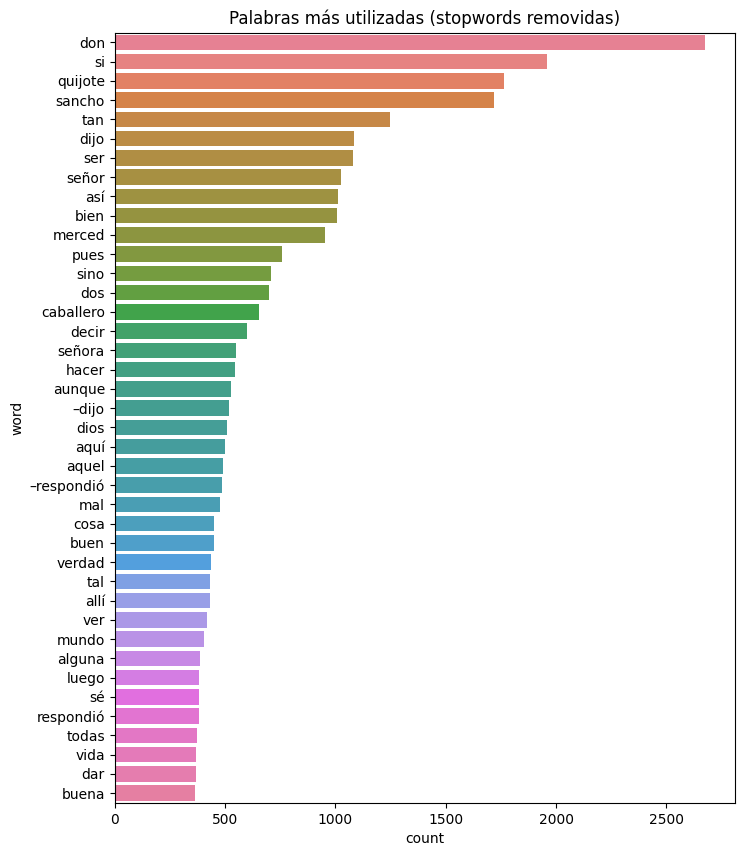

In [8]:
# Visualizar top40
top_df = pd.DataFrame(top40, columns=['word','count'])
plt.figure(figsize=(8,10))
sns.barplot(x='count', y='word', data=top_df, hue='word', legend=False)
plt.title('Palabras más utilizadas (stopwords removidas)')
plt.show()

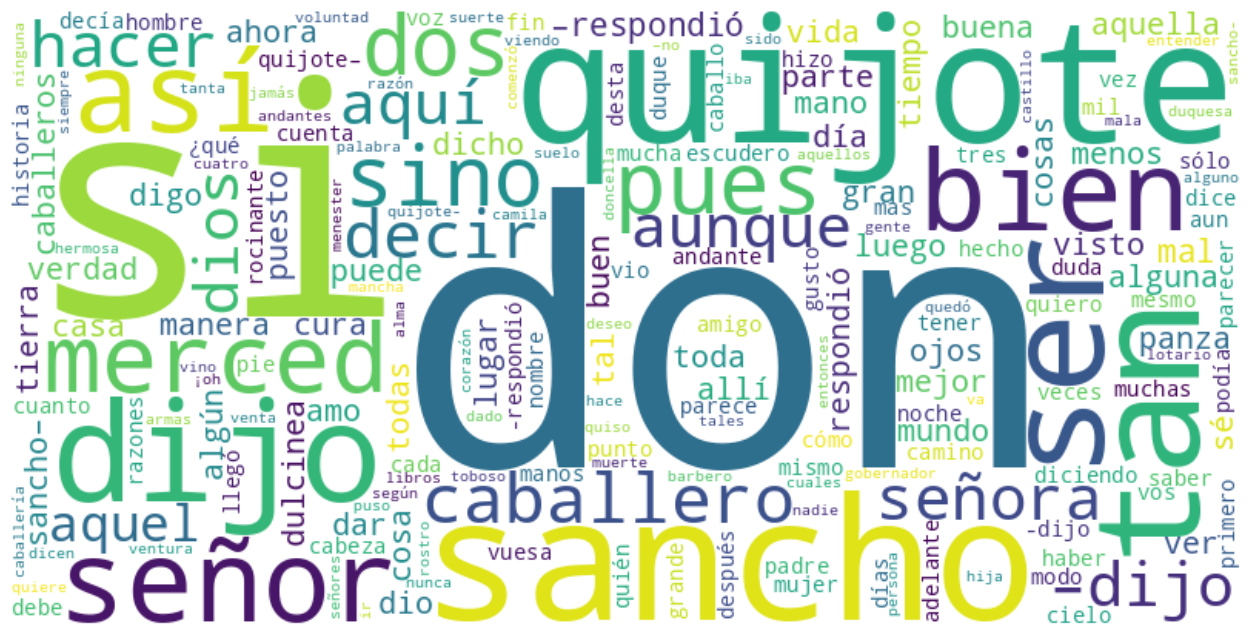

In [9]:
# Wordcloud
wc = WordCloud(background_color='white', width=800, height=400).generate_from_frequencies(counts)
plt.figure(figsize=(16,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [10]:
# 6. Bigramas por frase usando CountVectorizer (ngrams=2)
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words=list(sw), max_features=500)
X = vectorizer.fit_transform(df['frase'])
bigrams = zip(vectorizer.get_feature_names_out(), X.toarray().sum(axis=0))
bigram_counts = sorted(bigrams, key=lambda x: x[1], reverse=True)
bigram_counts[:30]  

[('don quijote', np.int64(2185)),
 ('dijo don', np.int64(323)),
 ('respondió sancho', np.int64(310)),
 ('sancho panza', np.int64(280)),
 ('respondió don', np.int64(270)),
 ('dijo sancho', np.int64(266)),
 ('vuesa merced', np.int64(245)),
 ('señor don', np.int64(183)),
 ('caballeros andantes', np.int64(131)),
 ('sancho dijo', np.int64(131)),
 ('caballero andante', np.int64(118)),
 ('quijote mancha', np.int64(117)),
 ('dulcinea toboso', np.int64(116)),
 ('don fernando', np.int64(114)),
 ('merced señor', np.int64(111)),
 ('señora dulcinea', np.int64(100)),
 ('muchas veces', np.int64(82)),
 ('quijote sancho', np.int64(76)),
 ('replicó don', np.int64(74)),
 ('quijote dijo', np.int64(72)),
 ('dijo cura', np.int64(70)),
 ('debe ser', np.int64(62)),
 ('don antonio', np.int64(62)),
 ('podría ser', np.int64(61)),
 ('sancho respondió', np.int64(61)),
 ('desta manera', np.int64(60)),
 ('así dijo', np.int64(58)),
 ('señor caballero', np.int64(58)),
 ('replicó sancho', np.int64(57)),
 ('quiero decir

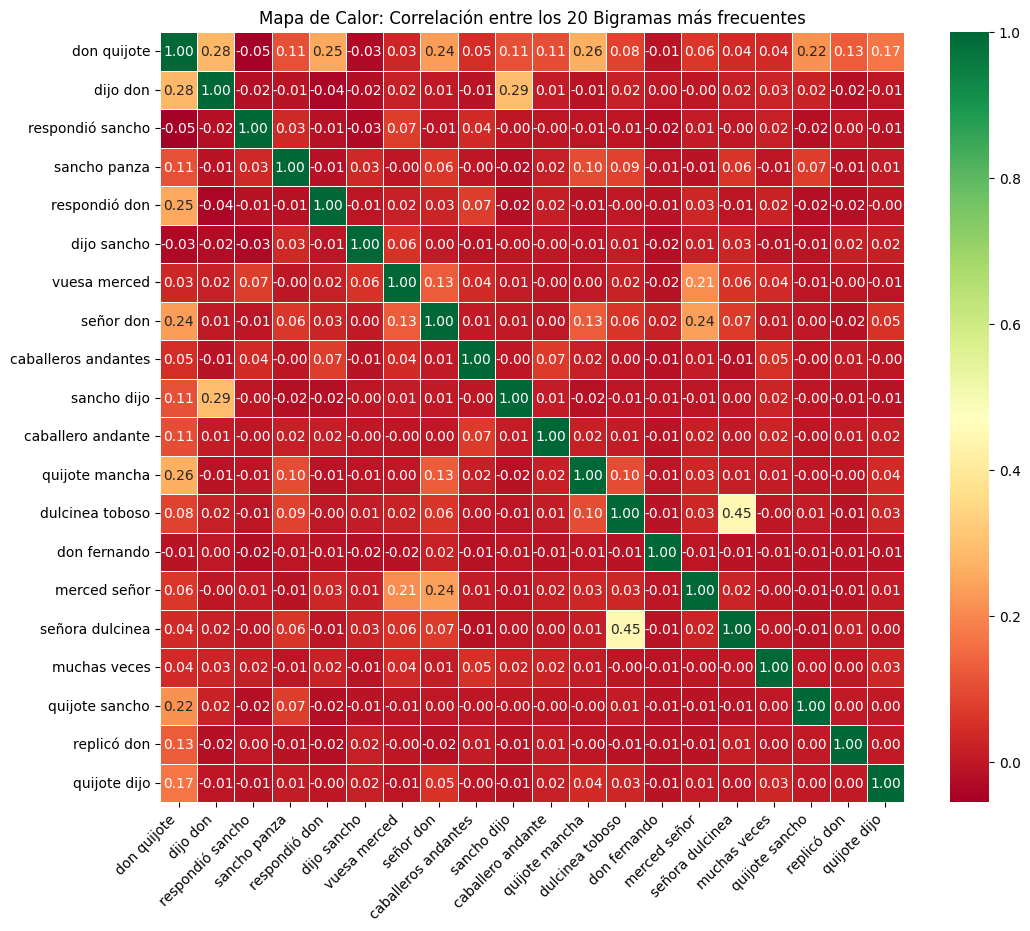

In [11]:
# Convertir la matriz dispersa a un DataFrame
# get_feature_names_out() obtiene los nombres de los bigramas (ej. 'don quijote')
df_bigramas = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Calcular la correlación entre columnas (bigramas)
matriz_corr = df_bigramas.corr("pearson")

# 1. Obtener la suma de frecuencias de cada bigrama
sum_words = X.sum(axis=0) 
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
# Ordenar de mayor a menor frecuencia
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# 2. Seleccionar los nombres de los TOP 20 bigramas
top_20_nombres = [word for word, freq in words_freq[:20]]
# Obtener sus índices en la matriz original
top_20_indices = [vectorizer.vocabulary_[word] for word in top_20_nombres]

# 3. Crear un DataFrame solo con esos 20 bigramas (reducimos de 137k a 20 columnas)
df_top20 = pd.DataFrame(X[:, top_20_indices].toarray(), columns=top_20_nombres)

# 4. Calcular la matriz de correlación
corr_matrix = df_top20.corr()

# 5. Graficar el Mapa de Calor
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True,      # Muestra los números de correlación
            cmap='RdYlGn',   # Verde (fuerte), Amarillo (neutra), Rojo (negativa)
            fmt=".2f",       # Dos decimales
            linewidths=0.5)

plt.title('Mapa de Calor: Correlación entre los 20 Bigramas más frecuentes')
plt.xticks(rotation=45, ha='right')
plt.show()


In [12]:
# 7. Grafo de co-ocurrencia: contar palabras por frase y crear aristas para pares que co-ocurren en la misma frase
min_count = 100
# construir parejas
pair_counts = Counter()
for tokens in df['tokens']:
    for a,b in combinations(set(tokens), 2):
        pair_counts[tuple(sorted((a,b)))] += 1

# Filtrar pares
edges = [(a,b,c) for (a,b),c in pair_counts.items() if c >= min_count]
len(edges)

203

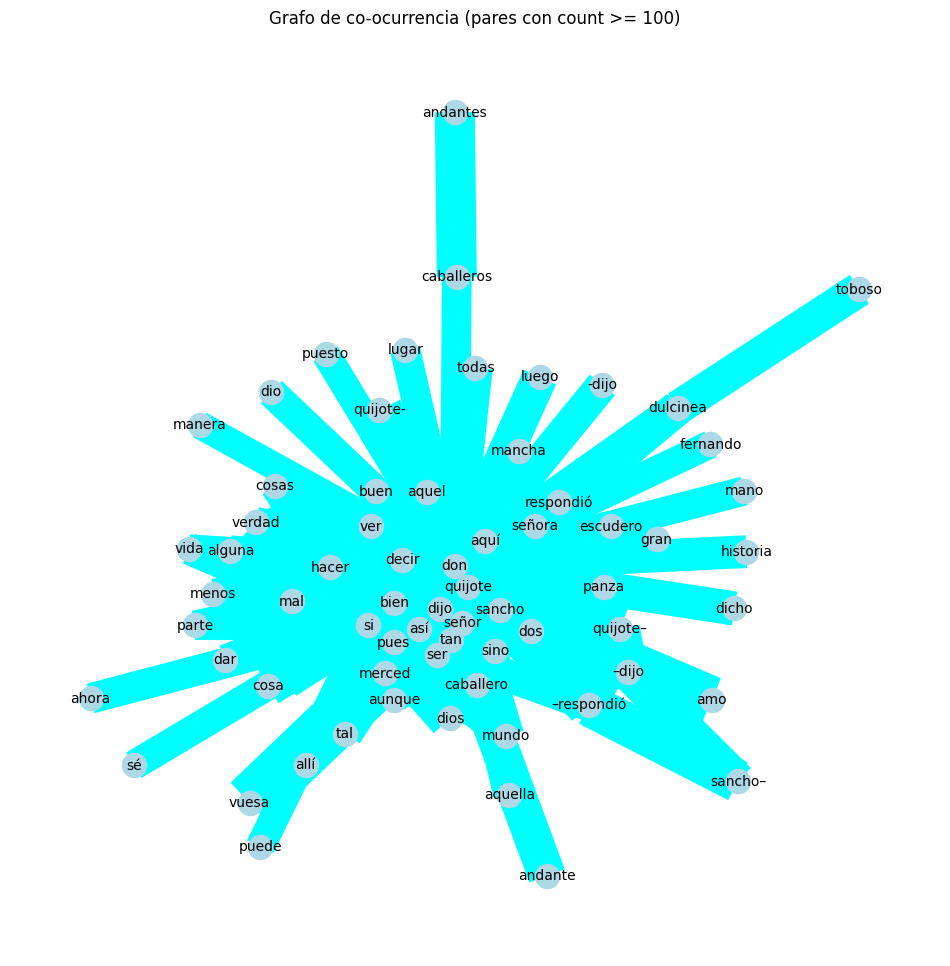

In [13]:
# Crear grafo y visualizar
G = nx.Graph()
for a,b,c in edges:
    G.add_edge(a,b,weight=c)

plt.figure(figsize=(12,12))
pos = nx.spring_layout(G, k=0.5)
weights = [G[u][v]['weight'] for u,v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_size=300, node_color='lightblue')
nx.draw_networkx_edges(G, pos, width=[w/5 for w in weights], edge_color='cyan')
nx.draw_networkx_labels(G, pos, font_size=10)
plt.title('Grafo de co-ocurrencia (pares con count >= {})'.format(min_count))
plt.axis('off')
plt.show()

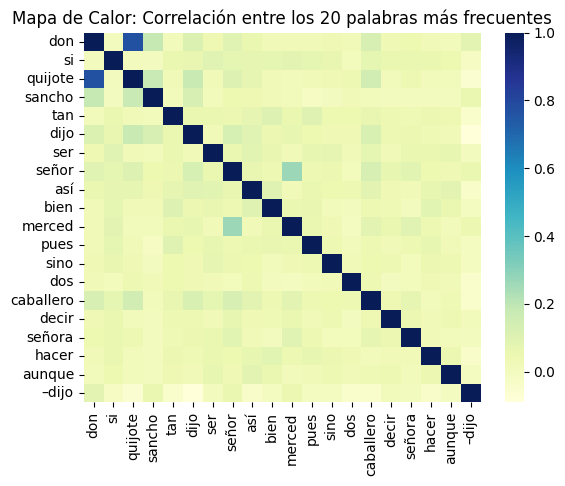

In [14]:
# Creamos una matriz de presencia (0 o 1) para las top 20 palabras
top_words = top_df.head(20)['word'].tolist()
for word in top_words:
    df[word] = df['tokens'].apply(lambda x: 1 if word in x else 0)

# Calculamos la matriz de correlación
matriz_corr = df[top_words].corr()

# Visualización rápida
sns.heatmap(matriz_corr, annot=False, cmap='YlGnBu')
plt.title('Mapa de Calor: Correlación entre los 20 palabras más frecuentes')
plt.show()

In [15]:
!pip install textblob

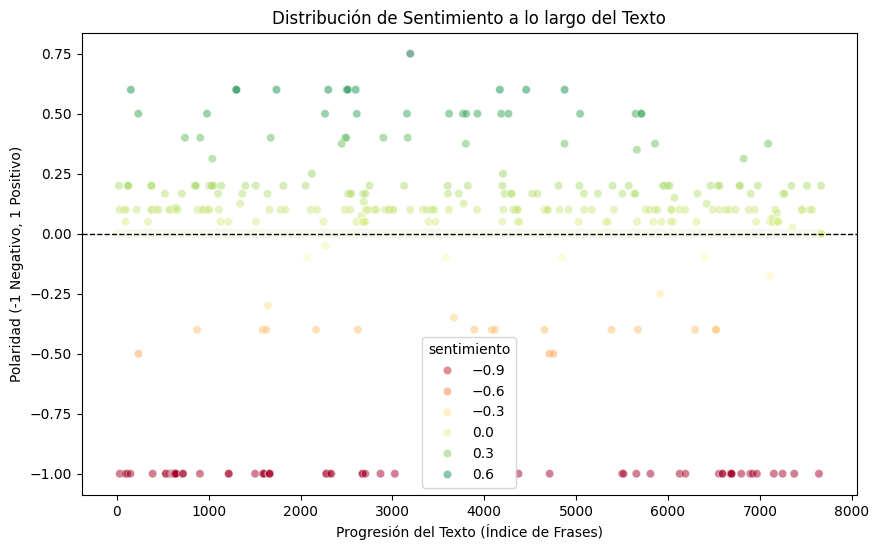

In [16]:
from textblob import TextBlob

def analizar_sentimiento(texto):
    # TextBlob funciona mejor en inglés, así que traducimos o usamos lexicones
    analysis = TextBlob(texto)
    # Traducir si es necesario: analysis = analysis.translate(from_lang='es', to='en')
    return analysis.sentiment.polarity # Devuelve de -1 (negativo) a 1 (positivo)

df['sentimiento'] = df['frase'].apply(analizar_sentimiento)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x=df.index, y='sentimiento', hue='sentimiento', palette='RdYlGn', alpha=0.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Línea de neutralidad
plt.title('Distribución de Sentimiento a lo largo del Texto')
plt.xlabel('Progresión del Texto (Índice de Frases)')
plt.ylabel('Polaridad (-1 Negativo, 1 Positivo)')
plt.show()

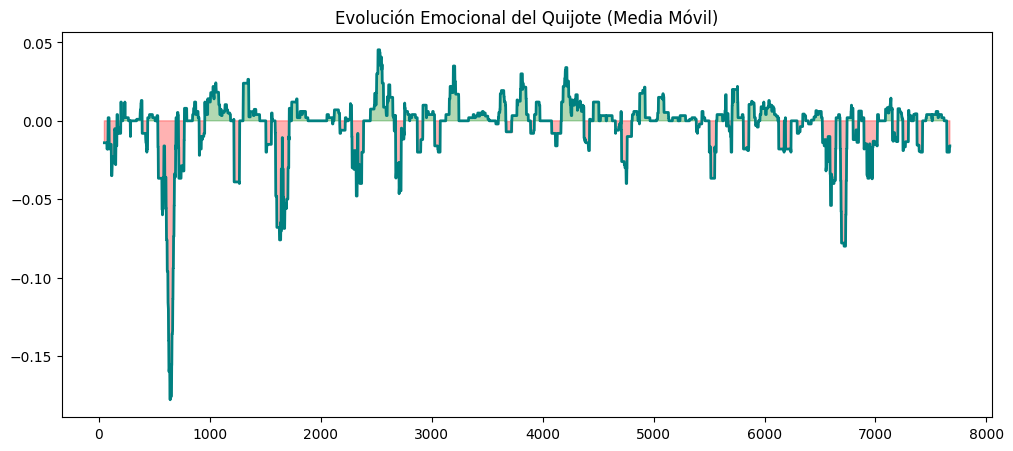

In [17]:
df['sentimiento_suavizado'] = df['sentimiento'].rolling(window=50).mean()

plt.figure(figsize=(12, 5))
plt.plot(df['sentimiento_suavizado'], color='teal', linewidth=2)
plt.fill_between(range(len(df)), df['sentimiento_suavizado'], 0, where=(df['sentimiento_suavizado'] > 0), color='green', alpha=0.3)
plt.fill_between(range(len(df)), df['sentimiento_suavizado'], 0, where=(df['sentimiento_suavizado'] < 0), color='red', alpha=0.3)
plt.title('Evolución Emocional del Quijote (Media Móvil)')
plt.show()

In [18]:
# 1. Encontrar el índice del valor mínimo en la media móvil
indice_minimo = df['sentimiento_suavizado'].idxmin()

# 2. Definir un rango alrededor de ese punto para tener contexto (ej. 5 frases antes y después)
rango_inicio = max(0, indice_minimo - 5)
rango_fin = min(len(df), indice_minimo + 5)

# 3. Mostrar el texto que causó la caída
print(f"--- El pico más negativo está cerca del índice: {indice_minimo} ---")
print(df.sort_values(by='sentimiento').head(5)['frase'].values)

--- El pico más negativo está cerca del índice: 641 ---
['Estas nuevas dieron un terrible empujón a los ojos preñados de ama, sobrina y de Sancho Panza, su buen escudero, de tal manera, que los hizo reventar las lágrimas de los ojos y mil profundos suspiros del pecho; porque, verdaderamente, como alguna vez se ha dicho, en tanto que don Quijote fue Alonso Quijano el Bueno, a secas, y en tanto que fue don Quijote de la Mancha, fue siempre de apacible condición y de agradable trato, y por esto no sólo era bien querido de los de su casa, sino de todos cuantos le conocían'
 'Don Quijote, arrimado a un tronco de una haya o de un alcornoque –que Cide Hamete Benengeli no distingue el árbol que era–, al son de sus mesmos su[s]piros, cantó de esta suerte: –Amor, cuando yo pienso en el mal que me das, terrible y fuerte, voy corriendo a la muerte, pensando así acabar mi mal inmenso; mas, en llegando al paso que es puerto en este mar de mi tormento, tanta alegría siento, que la vida se esfuerza y 

## Notas finales
- Si los PDFs no están en `task3/`, moverlos allí o actualizar las rutas.
- Para un grafo interactivo, considerar `pyvis` o `plotly`.
- Este notebook asume codificación UTF-8 y usa NLTK para tokenizar y stopwords.